# 20 · Studies, starting points and extensions

The last core tutorial covers what you need to *use* and *change* the Halo model: how its starting-point strategy works (and why it is not a
hidden convergence loop), how integer machine units and gear stages are handled, how to run studies cheaply by warm-starting, the other objectives,
and recipes for extending the model: a new submodel, a new requirement, a new component, with the tests that go with each.

**In this notebook**
1. The starting-point strategy: ordered precursor problems, `StartRecord`, local-optimum spread.
2. Discrete choices: integer machine units, gear-stage staircases, bus-voltage enumeration.
3. Warm-started studies: the Halo's growth factor; a sweep.
4. Other objectives: maximum payload around the fixed engines.
5. Extending the model: a new submodel, a new requirement, a new component.
6. Testing what you change.

**Run time:** about 2-3 minutes.

In [1]:
from tutorial_helpers import *
import numpy as onp
import inspect, time
from dataclasses import replace
import examples.halo_sizing as hs
from examples.halo_sizing import (HaloRequirements, HaloAssumptions, solve_halo_sizing, solve_halo_sizing_multistart,
                                  default_starts, requirements_tier16, assumptions_tier16, requirements_plan026, assumptions_plan026)

## 1. The starting-point strategy

IPOPT finds a local optimum near its start, and a large coupled problem can fail from a poor one (tutorials 02, 03, 16). The Halo answers with an
**explicit, finite, ordered list of starts**, each one complete solve of the target problem from an initial guess. A start may first solve a
simpler **precursor problem** (another battery model, Scholz aerodynamics, no thermal model, no redundancy, less payload) and use its solution as
the guess. Nothing is iterated to a fixed point: every coupling lives inside each solve, and the record says what was tried.

In [2]:
print(inspect.getsource(default_starts).split('"""')[1])
for label, (requirements, assumptions) in {"current reference": (HaloRequirements(), HaloAssumptions()),
                                           "plan 026 set": (requirements_plan026, assumptions_plan026),
                                           "tier 16 fast set": (requirements_tier16, assumptions_tier16)}.items():
    print(f"{label:<18} starts: {default_starts(requirements, assumptions, 'mass_takeoff')}")

The ordered candidate starts that apply to this problem (plan 029).

    0. "redundancy_off" / "strings_off" (Tier 18 redundancy): the same aircraft without redundancy, then (with
       battery strings) without the strings and their failure cases (plan 032).
    1. "electrical_off" (Tier 15 electrical layer with the thermal model): the same problem without the layer
       (plan 023: from the layer design without the thermal model IPOPT reaches local infeasibility). Without
       the thermal model it is a later fallback, after payload continuation.
       "thermal_off" (thermal model without the layer): the same problem without the thermal model (plan 028);
       from the generic guess, and with AeroBuildup from the thermal Scholz design, IPOPT can fail.
    2. "mass_objective" (objective "cost" only): the same problem at minimum take-off mass.
    3. "scholz_aero" (AeroBuildup only): the same problem with the Scholz hand-check aerodynamics (plan 025).
    4. "constant_battery" (equ

`select="first"` (the default) returns the first start that converges. `select="best"` tries all of them and returns the lowest objective, so the
record also measures the **spread between local optima**. On the plan 026 set (equivalent-circuit pack, AFDD wing, simple aerodynamics):

In [3]:
time_start_s = time.perf_counter()
with quiet_solver():          # a failing precursor prints many harmless CasADi NaN warnings
    best = solve_halo_sizing_multistart(requirements_plan026, assumptions_plan026, select="best")
print(f"{time.perf_counter() - time_start_s:.0f} s; returned start '{best.start.label}', {lb(best.mass_takeoff_kg):,.0f} lb")
for attempt in best.start.attempts:
    mass = f"{lb(attempt.mass_takeoff_kg):,.1f} lb" if attempt.success else attempt.message[:60]
    print(f"   {attempt.label:<22} {'converged' if attempt.success else 'failed   '}  {attempt.time_s:5.1f} s  {mass}")
print(f"spread over converged starts: {best.start.spread_mass_takeoff_kg():.2e} kg")
check("the plan 026 set reproduces its documented 14,247 lb", abs(lb(best.mass_takeoff_kg) - 14247) < 5)
check("all converged starts reach the same optimum (spread < 0.01 kg)", best.start.spread_mass_takeoff_kg() < 0.01)

45 s; returned start 'payload_continuation', 14,247 lb
   constant_battery       failed       7.2 s  Solver failed. You may use opti.debug.value to investigate t
   payload_continuation   converged   23.0 s  14,247.1 lb
   perturbed_low          converged    2.8 s  14,247.1 lb
   perturbed_high         converged    7.8 s  14,247.1 lb
   generic                converged    4.4 s  14,247.1 lb
spread over converged starts: 2.06e-06 kg
PASS  the plan 026 set reproduces its documented 14,247 lb
PASS  all converged starts reach the same optimum (spread < 0.01 kg)


Read the record: the constant-battery precursor failed here, the payload continuation (solve at 85 % payload, then use it) converged, and the
perturbed and generic starts reached the same optimum to a few milligrams: no evidence of competing local optima on this set. That is the kind of
evidence to collect before trusting a new configuration.

`solve_halo_sizing` (the public entry point) wraps this with two more explicit ladders:

- **integer machine units** (`machine_mass_model="units"`): solve with relaxed unit counts, round each up, re-solve with the counts fixed and the relaxed
  solution as the start (tutorial 05);
- **gear-stage staircase** (`GearStageModel(staircase=True)`): solve from its own start *and* from the relaxed (softplus) stage-count solution, keep
  the better (tutorial 03).

## 2. Discrete choices

An NLP has no integers. The code's three patterns:

| Choice | Pattern | Where |
|---|---|---|
| machine unit count | relax (smooth max), round up, re-solve fixed | `solve_halo_sizing`, `UnitMachineMassModel` |
| gear stages | smooth staircase or softplus relaxation; compare starts | `GearStageModel`, `solve_halo_sizing` |
| bus voltage (series cell count, inverter class) | **enumerate**: one independent sizing per option | `enumerate_bus_voltage` |
| redundancy architecture (lanes, buses, strings) | an assumption (Python integers in the topology); compare designs | `HaloAssumptions` |

Enumeration is the honest answer for a handful of discrete options: each option is a complete, independent solve, and the comparison is explicit.

In [4]:
print(inspect.getsource(hs.enumerate_bus_voltage).split('"""')[1])

Tier 15 discrete trade: one independent sizing per bus-voltage option (an explicit enumeration of a
    discrete choice, not a convergence loop). Returns ((option assumptions, result or None), ...); None marks
    an option that failed to solve.

    Every option starts from the same `initial` design; None uses the constant-battery aircraft without the
    electrical layer (the max-payload solve needs a constant-battery start, plan 022; see
    `solve_halo_max_payload`). An option that fails from it is retried from the previous option's solution and
    then from the nearest option that solved (different starting points only; each is one coupled solve).
    


## 3. Warm-started studies

A study changes an input and re-solves. Starting from a neighbouring solution (`initial=`) is faster and more robust than the strategy's precursors,
because the neighbour is already nearly optimal. With integer units, fix the counts so the study measures the continuous response, not a jump in
unit count.

**The Halo's growth factor.** Load tutorial 19's near-reference (Scholz aerodynamics, everything else at the reference) and add 50 kg of payload:

In [5]:
reference = cached("reference_scholz", lambda: solve_halo_sizing(HaloRequirements(), replace(HaloAssumptions(), aerodynamics_model="scholz")))
counts = {name: whole for name, (relaxed, whole) in reference.machine_units.items()}
fixed_units = replace(HaloAssumptions(), aerodynamics_model="scholz", count_units_motor=counts["motor"], count_units_generator=counts["generator"])
time_start_s = time.perf_counter()
heavier = solve_halo_sizing(replace(HaloRequirements(), mass_payload_kg=950.0), fixed_units, initial=reference)
growth = (heavier.mass_takeoff_kg - reference.mass_takeoff_kg) / 50.0
print(f"warm-started re-solve in {time.perf_counter() - time_start_s:.0f} s: {lb(heavier.mass_takeoff_kg):,.0f} lb; growth factor {growth:.2f} kg/kg")
check("the Halo's growth factor is between 2 and 4", 2.0 < growth < 4.0)

warm-started re-solve in 13 s: 15,411 lb; growth factor 2.51 kg/kg
PASS  the Halo's growth factor is between 2 and 4


Every kilogram added anywhere costs about 2.5 kg of take-off mass, once the engines' fixed power, the battery, rotors, drive, structure and fuel all
respond. That is why empty-weight uncertainty matters so much (tutorial 22).

**A sweep, chained.** On the fast set (2-3 s per solve), sweep the range, each solve starting from the previous one:

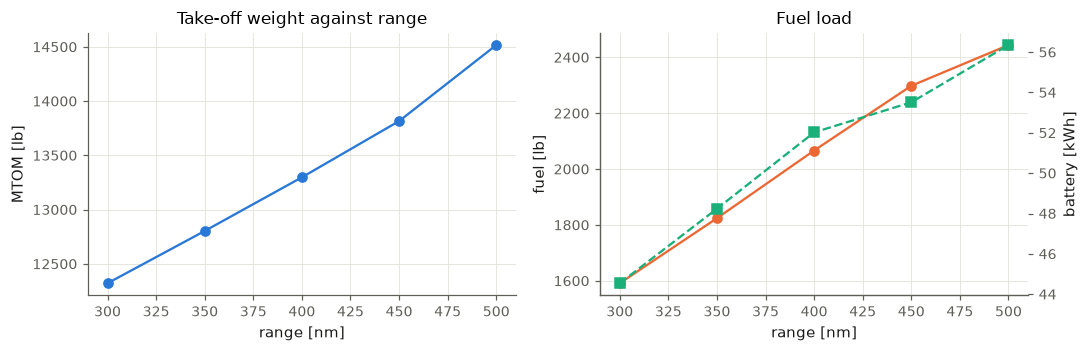

PASS  take-off mass grows with range


In [6]:
ranges_nm = onp.arange(300, 601, 50)
rows, previous = [], None
for range_nm in ranges_nm:
    requirements = replace(requirements_tier16, range_m=range_nm * 1852.0)
    try:
        result = solve_halo_sizing(requirements, assumptions_tier16, initial=previous) if previous else solve_halo_sizing(requirements, assumptions_tier16)
        rows.append((range_nm, result.mass_takeoff_kg, result.mass_fuel_kg, result.energy_battery_kWh))
        previous = result
    except RuntimeError:
        rows.append((range_nm, onp.nan, onp.nan, onp.nan))
rows = onp.array(rows)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
axes[0].plot(rows[:, 0], lb(rows[:, 1]), "o-", color=blue); axes[0].set(xlabel="range [nm]", ylabel="MTOM [lb]", title="Take-off weight against range")
axes[1].plot(rows[:, 0], lb(rows[:, 2]), "o-", color=orange, label="fuel [lb]")
axes[1].set(xlabel="range [nm]", ylabel="fuel [lb]", title="Fuel load")
ax2 = axes[1].twinx(); ax2.plot(rows[:, 0], rows[:, 3], "s--", color=aqua, label="battery [kWh]"); ax2.set_ylabel("battery [kWh]")
ax2.grid(False); plt.tight_layout(); plt.show()
check("take-off mass grows with range", onp.all(onp.diff(rows[~onp.isnan(rows[:, 1]), 1]) > 0))

Fuel grows with range; the battery does not (it is sized by the engine-out reserve, not the mission).

## 4. Other objectives

`objective="payload"` makes payload a variable and maximizes it: the aircraft sized around the fixed engines. `"cost"` minimizes cost per mission.
Both are one argument:

In [7]:
time_start_s = time.perf_counter()
max_payload = solve_halo_sizing(requirements_tier16, assumptions_tier16, objective="payload", initial=previous)
print(f"maximum payload on the fast set: {max_payload.mass_payload_kg:,.0f} kg at {lb(max_payload.mass_takeoff_kg):,.0f} lb "
      f"({time.perf_counter() - time_start_s:.0f} s)")
check("maximum payload exceeds the 900 kg requirement (the 900 kg design has slack in its engines)", max_payload.mass_payload_kg > 900.0)

CasADi - 2026-10-09 07:55:38 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 121, col 0).") [.../casadi/core/oracle_function.cpp:408]


maximum payload on the fast set: 1,014 kg at 14,618 lb (3 s)
PASS  maximum payload exceeds the 900 kg requirement (the 900 kg design has slack in its engines)


## 5. Extending the model

The architecture makes most extensions local. Three recipes, from smallest to largest.

### (a) A new submodel: drop-in, no other change

Any object with the right method fills a submodel slot (tutorial 04). A machine loss model whose copper loss rises with winding temperature, say,
needs only `evaluate(speed_rad_s, torque_Nm, voltage_V)`. Here a loss model that adds a voltage-dependent inverter-like term, plugged into a motor and
used inside an Opti with no change to `Motor`:

In [8]:
from dataclasses import dataclass
from typing import Any
from aircraft_closure.powertrain.components.motor import Motor, McDonaldMotorLossModel, TorqueDensityMassModel, rubber_machine

@dataclass(frozen=True)
class VoltageSensitiveLossModel:
    """McDonald losses plus a conduction-like term that grows as the bus voltage sags (illustrative)."""
    base: Any = McDonaldMotorLossModel()
    coefficient_W: Any = 500.0              # extra loss at the reference voltage and torque (assumed)
    voltage_ref_V: Any = 800.0
    torque_ref_Nm: Any = 200.0

    def evaluate(self, speed_rad_s, torque_Nm, voltage_V):
        return (self.base.evaluate(speed_rad_s, torque_Nm, voltage_V)
                + self.coefficient_W * (torque_Nm / self.torque_ref_Nm)**2 * (self.voltage_ref_V / voltage_V)**2)

motor = Motor(loss_model=VoltageSensitiveLossModel())
for voltage_V in (800.0, 650.0, 525.0):
    r = motor.evaluate(400.0, 200.0, voltage_V)
    print(f"{voltage_V:5.0f} V: efficiency {r.power_shaft_W / r.power_electric_W:.4f}")
opti = asb.Opti()
torque_Nm = opti.variable(init_guess=150.0, scale=100.0)
r = motor.evaluate(400.0, torque_Nm, 700.0)
opti.subject_to(r.power_shaft_W / 50e3 == 1)
print("works symbolically:", round(float(opti.solve(verbose=False).value(r.power_loss_W)), 2), "W loss at 50 kW")

  800 V: efficiency 0.9543
  650 V: efficiency 0.9514
  525 V: efficiency 0.9468
works symbolically: 2572.81 W loss at 50 kW


To use it in the Halo, `build_halo_aircraft` would pass it to `rubber_machine(..., loss_model=...)` behind a new `HaloAssumptions` switch (keeping the
old model available), plus a unit test of its limiting cases.

### (b) A new requirement

Checklist (the hot-day hover is the template in `solve_halo_sizing_once`):

1. add fields to `HaloRequirements` (with a switch and documented defaults);
2. in `solve_halo_sizing_once`, build the point (`build_flight_point`) or a short mission (`build_mission`, for SOC accounting) with the right mass and
   SOC (MTOM, or `flown.mass_end_kg` / `flown.soc_end`);
3. append its margins (and any new `margin_above/below`) to `all_margins`;
4. report it in `HaloSizingResult`;
5. add an integration test asserting it binds or not, and its effect on a fast set.

### (c) A new component type

Checklist (Tier 15's cable and Tier 18's contactors went this way; `docs/decisions/023`, `032`):

1. the class in `powertrain/components/` with `get_mass`, `get_limits`, `evaluate`, a docstring of equations and sources, and a `__main__` sanity case;
2. its ports in `powertrain/ports.py`;
3. its operating margins in `powertrain/compatibility.py` (and design margins if adjacent ratings matter);
4. its place in the network (`powertrain/topologies.py`, behind an optional argument so the plain topology is unchanged);
5. its physics in `build_flight_point` (the topology alone couples nothing), its heat as a `HeatLoad`;
6. its location in the `PowertrainInstallation`;
7. unit tests (identities, limits, trends), an integration test that the defaults are unchanged with it off, and a decision record.

## 6. Testing what you change

The test suite mirrors `src/` (unit tests) and reproduces documented results (`tests/integration/`). Run one file or one class, not the whole suite
(10-17 minutes). For example, the rotor and topology tests:

In [9]:
import subprocess, sys, os
completed = subprocess.run([sys.executable, "-m", "unittest", "tests.powertrain.test_rotor", "tests.core.test_topology"], cwd=repo_root,
                           capture_output=True, text=True, env=dict(os.environ, PYTHONPATH=str(repo_root / "src") + os.pathsep + str(repo_root),
                                                                   OMP_NUM_THREADS="1"))
for line in completed.stderr.strip().splitlines()[-3:]:
    print(line)
check("the targeted tests pass", completed.returncode == 0)

Ran 34 tests in 0.133s

OK
PASS  the targeted tests pass


Set `OMP_NUM_THREADS=1` when running several solves at once: threaded linear algebra under contention makes IPOPT fail spuriously.

## Summary

- Starts are an explicit, ordered, finite list of complete solves (precursor problems, perturbations, a generic guess); `StartRecord` says what happened
  and `select="best"` measures local-optimum spread.
- Integers are relaxed and re-solved (units), smoothed (stages) or enumerated (bus voltage).
- Studies warm-start from a neighbour with `initial=`; fix integer counts to measure continuous sensitivities. The Halo's growth factor is about 2.5.
- Objectives are one argument. Extensions are local: a submodel fills a slot; a requirement adds a point and margins; a component touches ports,
  margins, topology, flight point and installation, and each comes with tests.

## Check yourself

<details><summary>1. Why is the multistart strategy not a "hidden iteration" in the sense the coding rules forbid?</summary>

Each start is an independent, complete solve of the same coupled problem from a different initial guess; no quantity is passed back and forth to converge. The list is finite and ordered, and the record reports every attempt.
</details>

<details><summary>2. You change an assumption and the reference no longer solves from its own strategy. What do you try?</summary>

Warm-start from the old reference (`initial=`); step the assumption in stages (a continuation through intermediate values, each a complete solve); solve a precursor without the new feature and start from it; check the IPOPT log (`verbose=True`) for restoration phases or tiny steps, which point to a kink, bad scaling or a genuinely infeasible requirement.
</details>

In [10]:
check_summary()

6 of 6 checks passed
